# Intra patient mapping

In [41]:
import glob
import os
import vtk
vtk.vtkObject.GlobalWarningDisplayOff()
import sys
import numpy as np
import pandas as pd
import seaborn as sns#; sns.set()
import matplotlib.pyplot as plt
from scipy.stats import kruskal, wilcoxon, linregress, norm, fisher_exact, mannwhitneyu
from scipy.ndimage import gaussian_filter
from scipy.interpolate import make_interp_spline, BSpline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk
from sklearn.mixture import GaussianMixture

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile, ReadVTKFile


In [42]:
plt.rcParams['font.family'] = 'Helvetica'#'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Helvetica' #'Times New Roman'
font1 = {'color':'black','size':23, 'family':'Helvetica'}
font2 = {'color':'black','size':20, 'family':'Helvetica'}

color1 = '#1B7F79' #deep teal
color2 = '#E07B39' #soft orange
color3 = '#4C6EF5' # Slate Blue
color4 = '#E0A458' # Amber Gold
color5 = '#2F3E46' # Muted Navy Blue
color6 = '#7A8A8F' # Warm Slate Gray
color7 = '#8B6F9C' # Dusty Purple
color8 = '#8FA98C' # Olive Green (Desaturated)
color9 = '#E6D8B8' # Warm Beige
color10 = '#4D4D4D' # Dark Gray
color11 = '#009E73' # Bluish Green

color_set1 = ['#8FBCBB', '#BF616A', '#5E81AC']

In [43]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

nr_path = '/Volumes/T7_Research/CABG/05_PrePostCABG/NonRegistered'
VTKFiles = sorted(glob.glob(f"{nr_path}/*.vtk"))

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [44]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [50]:
def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def robust_mode(data, bins=50):
    counts, bin_edges = np.histogram(data, bins=bins)
    max_bin_index = np.argmax(counts)
    mode_value = (bin_edges[max_bin_index] + bin_edges[max_bin_index + 1]) / 2
    return mode_value

def Normalize(MBF, method="mode", cutoff = 50):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
        arrayname_ = MBF.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ArrayName = arrayname_
    
    ScalarArray = vtk_to_numpy(MBF.GetPointData().GetArray(ArrayName))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(MBF, ArrayName, cutoff))
    HealthyMyo = LargestConnectedRegion(ThresholdInBetween(MBF, ArrayName, np.percentile(ScalarArray,10), np.percentile(ScalarArray,90)))
    #HealthyMyo = LargestConnectedRegion(ThresholdByUpper(HealthyMyo, ArrayName, cutoff))
    ScalarArray_healthy = vtk_to_numpy(HealthyMyo.GetPointData().GetArray(ArrayName))
    
    if method == "mode": # Histogram Analysis
        # Using Freedman-Diaconis Rule to calculate the number of bins based on IQR
        IQR = np.percentile(ScalarArray_healthy, 75) - np.percentile(ScalarArray_healthy, 25)
        bin_width = 2*IQR/(len(ScalarArray_healthy))**(1/3)
        MBF_range = np.max(ScalarArray_healthy) - np.min(ScalarArray_healthy)
        bins = int(MBF_range/bin_width)
        ref_MBF = robust_mode(ScalarArray_healthy, bins)
    elif method == "median":
        ref_MBF = np.median(ScalarArray_healthy)
    elif method == "mean":
        ref_MBF = np.mean(ScalarArray_healthy)
    elif method == "classic":
        ref_MBF = np.percentile(ScalarArray, 75)
    elif method == "zscore":
        q1, q2, q3 = np.percentile(ScalarArray_healthy, [25, 50, 75])
        IndexMBFArray = (ScalarArray - q2)/(q3 - q1)
        IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
        IndexMBF = numpy_to_vtk(IndexMBFArray)
        IndexMBF.SetName("IndexMBF")
        MBF.GetPointData().AddArray(IndexMBF)

        return MBF
    else:
        ref_MBF = np.percentile(ScalarArray_healthy, 75)

    IndexMBFArray = ScalarArray/ref_MBF
    #IndexMBFArray = gaussian_filter(IndexMBFArray, sigma=1)
    IndexMBF = numpy_to_vtk(IndexMBFArray)
    IndexMBF.SetName("IndexMBF")
    MBF.GetPointData().AddArray(IndexMBF)

    return MBF

def GetVolume(Grid):
    Volume = 0
    for i in range(Grid.GetNumberOfCells()):
        voxel = Grid.GetCell(i)
        cell_bounds = voxel.GetBounds()
        Volume += abs(cell_bounds[0] - cell_bounds[1]) * abs(cell_bounds[2] - cell_bounds[3]) * abs(cell_bounds[4] - cell_bounds[5])
    
    return Volume

def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    #IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        #IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            #iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            #IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)
    

    return AbsMBFData#, IndexMBFData

def GetRegionVolume(MBF, Labels, key):
    volume = 0

    for i in Labels[key]:
        territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
        volume += GetVolume(territory_)
    
    return volume

def BoxPlot(DataFrame):
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(x='Territories', y='MBF', hue='Type', data= DataFrame, showfliers=False, palette={'A':'skyblue', 'B':'salmon'})

    ax.set_ylabel("Index MBF", fontsize = 20)
    ax.tick_params(axis='x', rotation=10, labelsize=15)
    ax.legend(loc = 'upper left')
    plt.tight_layout()
    plt.show()

def ViolinPlot(DataFrame):
    plt.figure(figsize=(7.5, 5.5))

    sns.violinplot(x='Territories', y='MBF', hue='Type', data = DataFrame, split=True, inner = 'quartiles', bw_adjust = 10, common_norm=True, linewidth=2.5, fill= False, gap=.1, palette={'Baseline':color1, 'Follow-up':color2})

    plt.ylabel("Myocardial Blood Flow\n(mL/min/100mL)", fontsize = 23)
    plt.tick_params(axis= 'x', labelsize = 18)
    plt.xticks(fontsize = 20, rotation=90)
    plt.yticks(fontsize = 18)
    #plt.xlabel("Group")
    plt.legend(fontsize = 16, loc="upper left")
    plt.ylim([-200, 800])
    plt.show()

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    return meanB + (stdB/stdA)*(DataA - meanA)

def ShiftMBF(refA, refB, DataA):
    return DataA - (refA - refB)

def Map3DVolume(meanA, meanB, stdA, stdB, VolumeA):
    for i in range(VolumeA.GetPointData().GetNumberOfArrays()):
            arrayname_ = VolumeA.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(VolumeA.GetPointData().GetArray(ScalarArray))
    ScalarData_Mapped = numpy_to_vtk(MapNongrafted(meanA, meanB, stdA, stdB, ScalarData))
    MappedScalarArrayName = "MappedScalar"
    ScalarData_Mapped.SetName(MappedScalarArrayName)
    VolumeA.GetPointData().AddArray(ScalarData_Mapped)

    return VolumeA

def ReturnMedianMBF(Volume):
    for i in range(Volume.GetPointData().GetNumberOfArrays()):
        arrayname_ = Volume.GetPointData().GetArrayName(i)
        if 'scalars' in arrayname_.lower():
            ScalarArray = arrayname_

    ScalarData = vtk_to_numpy(Volume.GetPointData().GetArray(ScalarArray))
    return np.median(ScalarData)

def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2)
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value


def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_



In [46]:
Removed_Cases = ["SU25", "VA04"]

## Creating the patient's dataframe

In [ ]:
ReadVTUFiles = np.vectorize(ReadVTUFile)

def GetBaseName(file):
    return os.path.basename(os.path.splitext(file)[0])

GetBaseNames = np.vectorize(GetBaseName)

BaseNames = GetBaseNames(np.array(VTUFiles))
VTUVolumes = ReadVTUFiles(np.array(VTUFiles))

print(BaseNames)
print(VTUVolumes)

['SU03A_MBF_Territories' 'SU03B_MBF_Territories' 'SU04A_MBF_Territories'
 'SU04B_MBF_Territories' 'SU06A_MBF_Territories' 'SU06B_MBF_Territories'
 'SU07A_MBF_Territories' 'SU07B_MBF_Territories' 'SU10A_MBF_Territories'
 'SU10B_MBF_Territories' 'SU11A_MBF_Territories' 'SU11B_MBF_Territories'
 'SU13A_MBF_Territories' 'SU13B_MBF_Territories' 'SU14A_MBF_Territories'
 'SU14B_MBF_Territories' 'SU16A_MBF_Territories' 'SU21A_MBF_Territories'
 'SU21B_MBF_Territories' 'SU23A_MBF_Territories' 'SU23B_MBF_Territories'
 'SU24A_MBF_Territories' 'SU24B_MBF_Territories' 'SU25A_MBF_Territories'
 'SU25B_MBF_Territories' 'SU26A_MBF_Territories' 'SU26B_MBF_Territories'
 'SU27A_MBF_Territories' 'SU27B_MBF_Territories' 'SU28A_MBF_Territories'
 'SU28B_MBF_Territories' 'SU30A_MBF_Territories' 'SU30B_MBF_Territories'
 'SU33A_MBF_Territories' 'SU33B_MBF_Territories' 'SU34A_MBF_Territories'
 'SU34B_MBF_Territories' 'VA02A_MBF_Territories' 'VA02B_MBF_Territories'
 'VA04A_MBF_Territories' 'VA04B_MBF_Territories' 'V

: 

In [ ]:
def GetMBFArray(VTUVolume):
    ScalaraArrayName = GetScalarArrayName(VTUVolume)
    MBF_array = vtk_to_numpy(VTUVolume.GetPointData().GetArray(ScalaraArrayName))
    return MBF_array

: 

In [ ]:
BaseNames

array(['SU03A_MBF_Territories', 'SU03B_MBF_Territories',
       'SU04A_MBF_Territories', 'SU04B_MBF_Territories',
       'SU06A_MBF_Territories', 'SU06B_MBF_Territories',
       'SU07A_MBF_Territories', 'SU07B_MBF_Territories',
       'SU10A_MBF_Territories', 'SU10B_MBF_Territories',
       'SU11A_MBF_Territories', 'SU11B_MBF_Territories',
       'SU13A_MBF_Territories', 'SU13B_MBF_Territories',
       'SU14A_MBF_Territories', 'SU14B_MBF_Territories',
       'SU16A_MBF_Territories', 'SU21A_MBF_Territories',
       'SU21B_MBF_Territories', 'SU23A_MBF_Territories',
       'SU23B_MBF_Territories', 'SU24A_MBF_Territories',
       'SU24B_MBF_Territories', 'SU25A_MBF_Territories',
       'SU25B_MBF_Territories', 'SU26A_MBF_Territories',
       'SU26B_MBF_Territories', 'SU27A_MBF_Territories',
       'SU27B_MBF_Territories', 'SU28A_MBF_Territories',
       'SU28B_MBF_Territories', 'SU30A_MBF_Territories',
       'SU30B_MBF_Territories', 'SU33A_MBF_Territories',
       'SU33B_MBF_Territories',

: 

In [ ]:
np.char.find(BaseNames, 'SU04B')

array([-1, -1, -1,  0, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1])

: 

In [ ]:
np.where(np.char.find(BaseNames, 'SU04B') != -1)[0].item()

3

: 

### Mapping based on the non-grafted (pre on post)

SU03
shift the mean


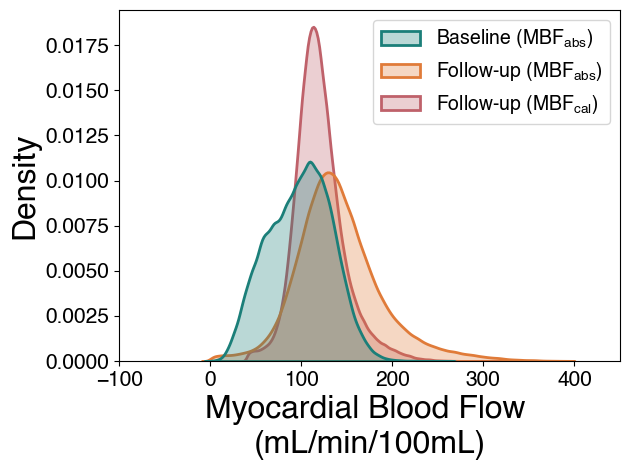

SU04
shift the mean


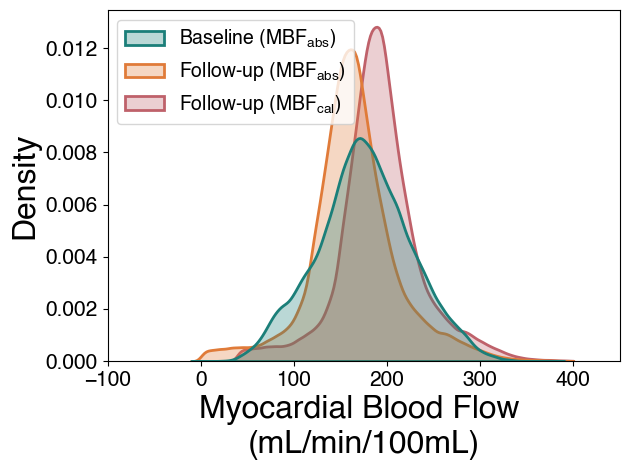

SU06
shift the mean


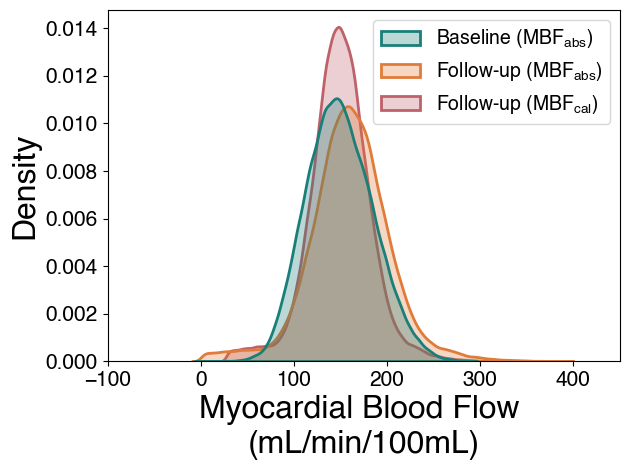

SU07
shift the mean


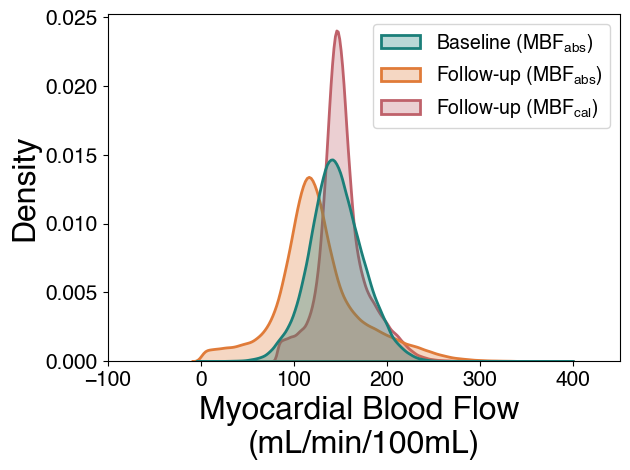

SU10
shift the mean


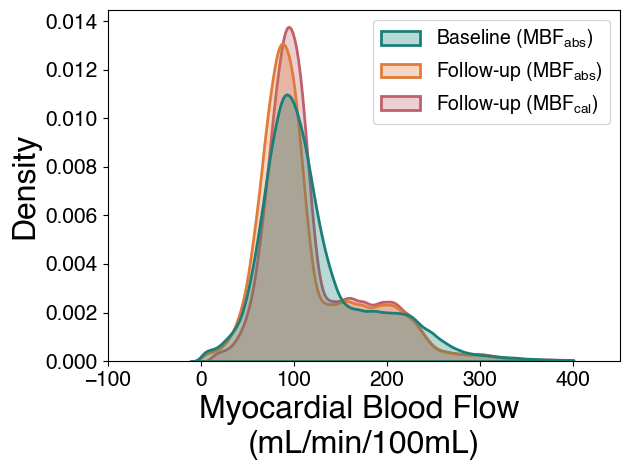

SU11
shift the mean


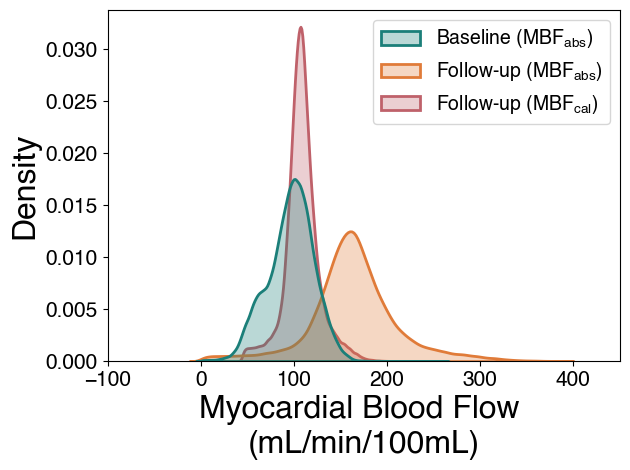

SU13
shift the mean


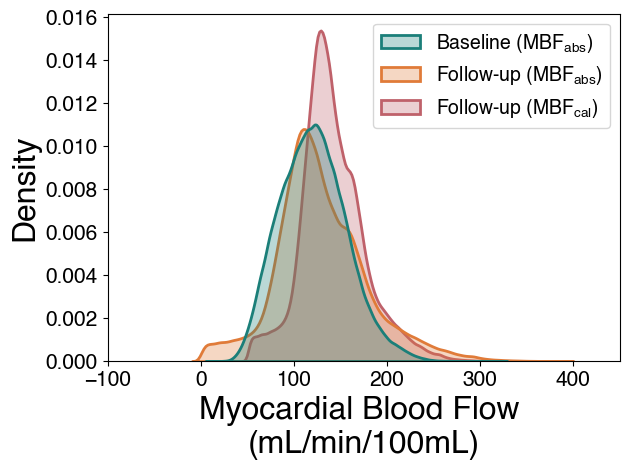

SU14
shift the mean


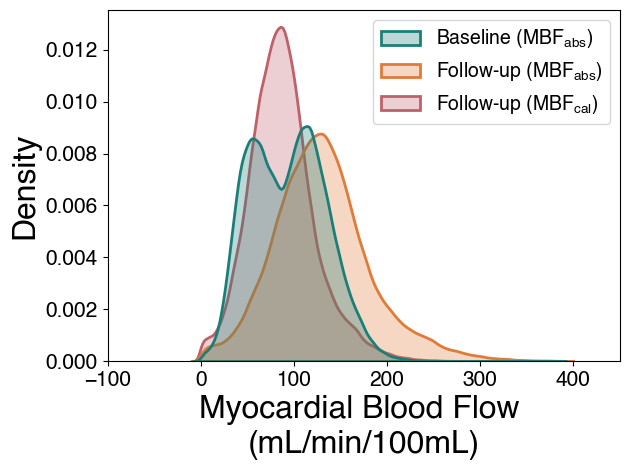

SU16
shift the mean


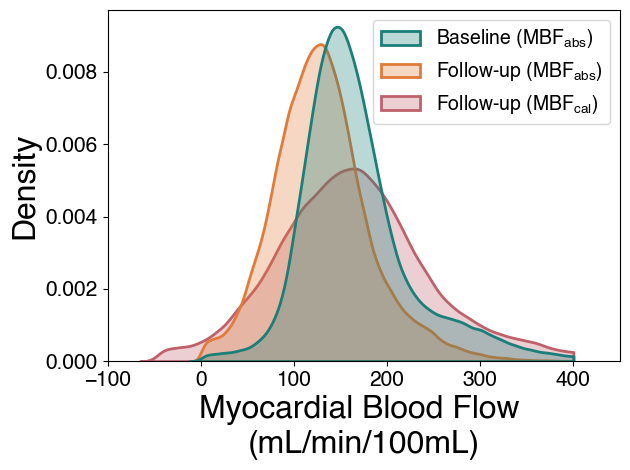

SU21
shift the mean


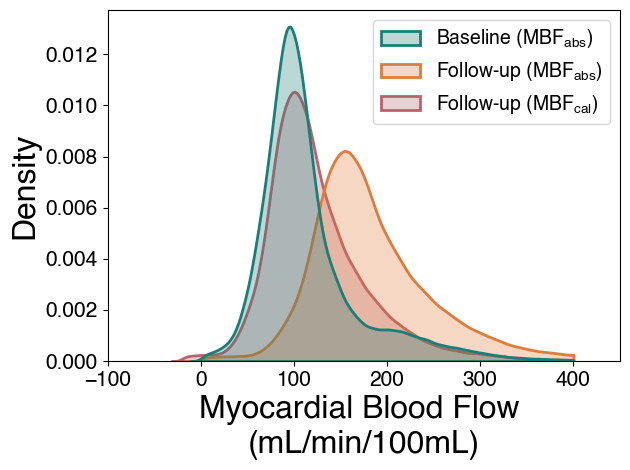

SU23
shift the mean


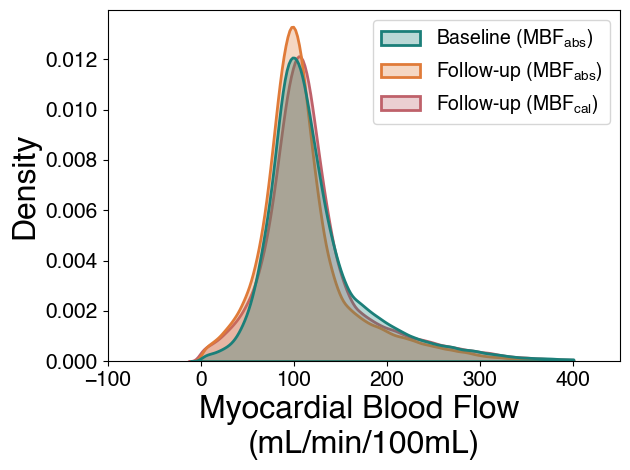

SU24
shift the mean


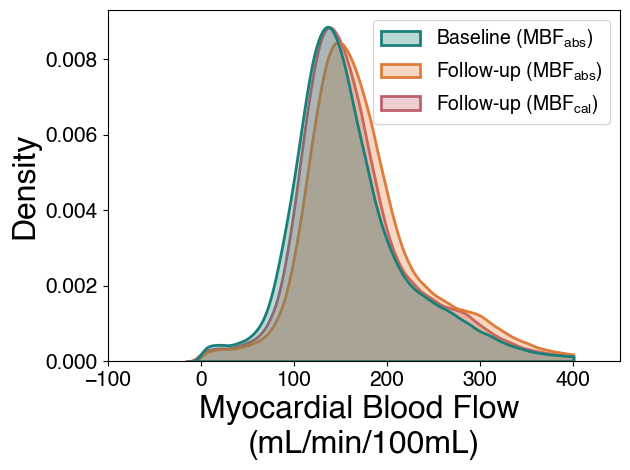

SU26
shift the mean


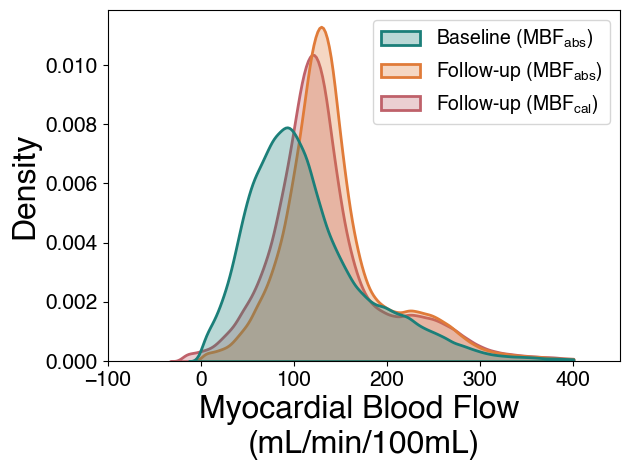

SU27
shift the mean


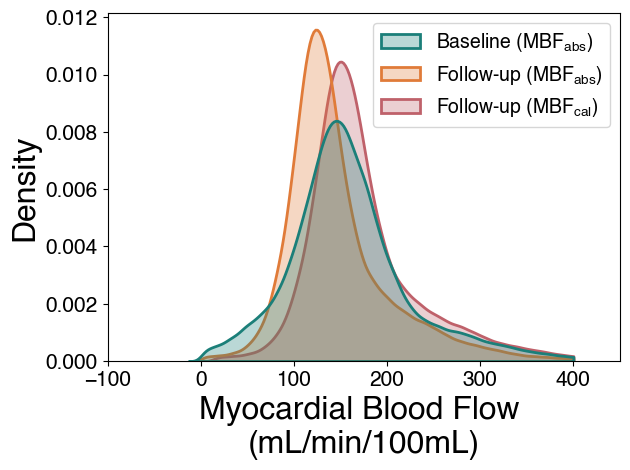

SU28
shift the mean


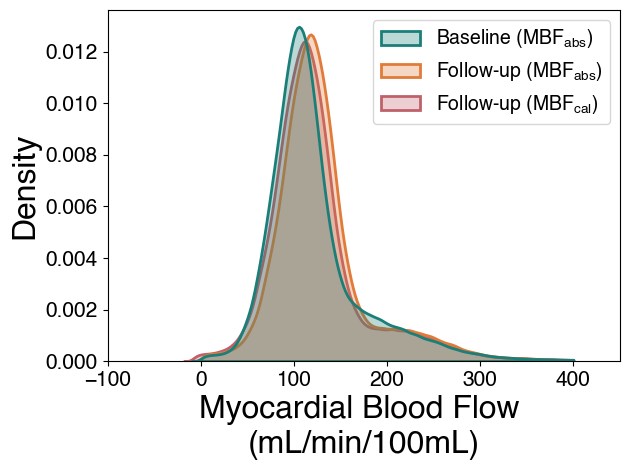

SU30
shift the mean


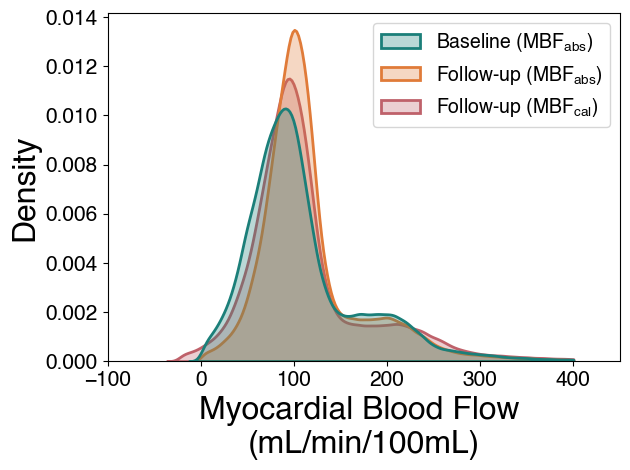

SU33
shift the mean


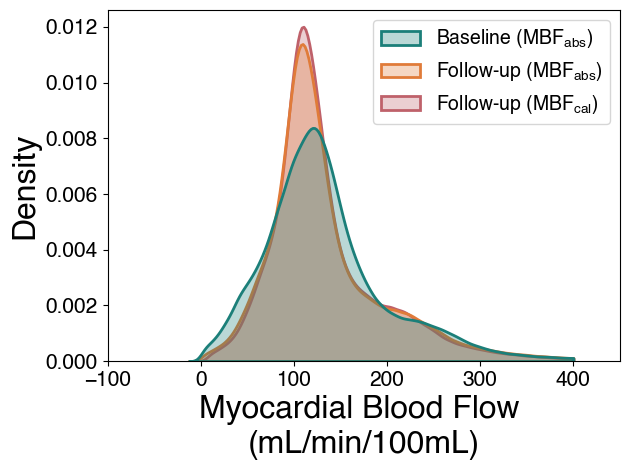

SU34
shift the mean


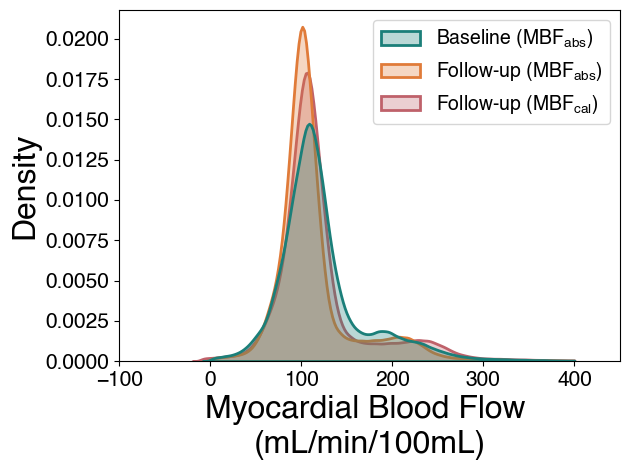

VA02
shift the mean


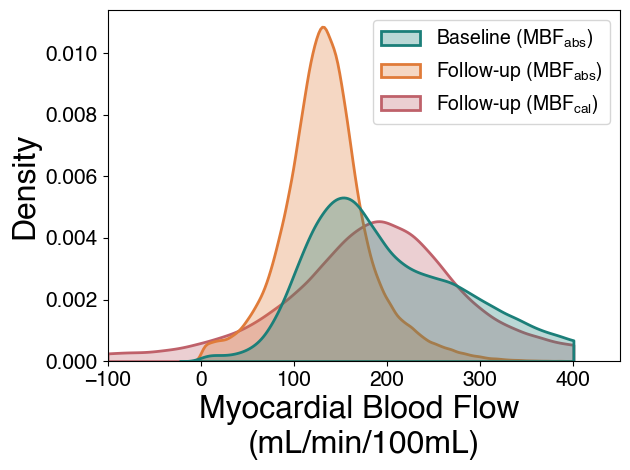

VA06
shift the mean


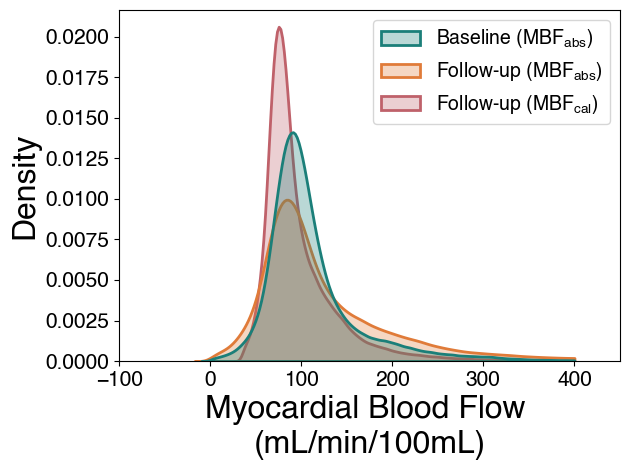

VA08
shift the mean


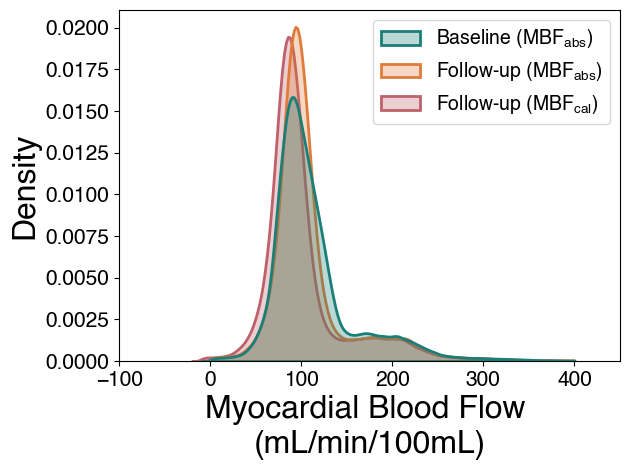

VA10
shift the mean


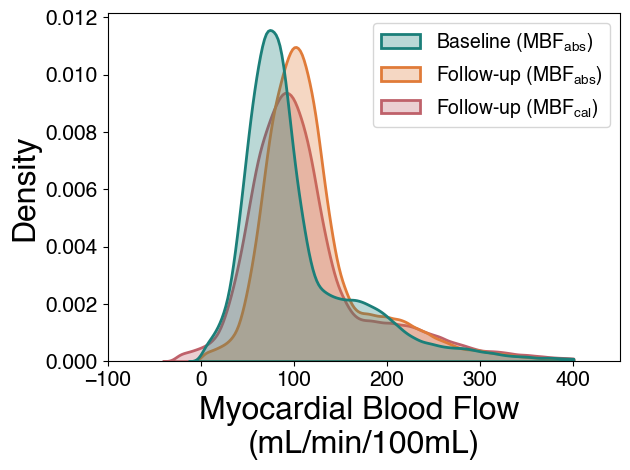

VA13
shift the mean


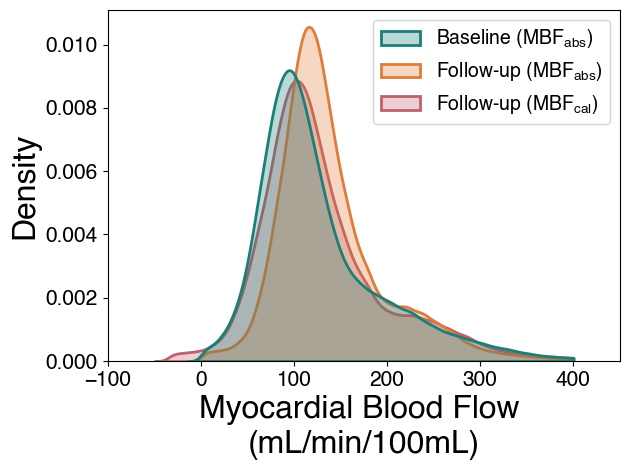

VA14
shift the mean


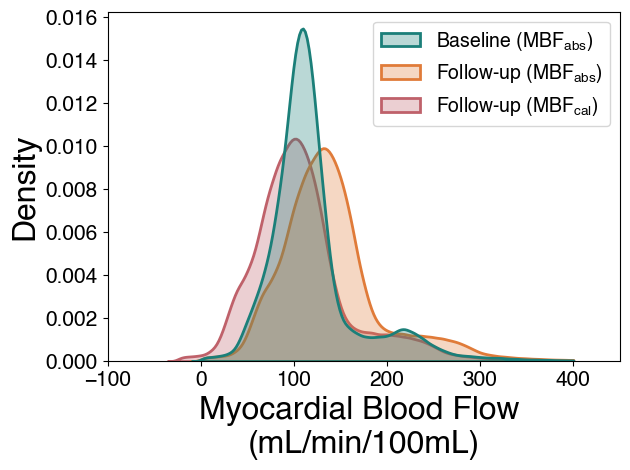

VA16
shift the mean


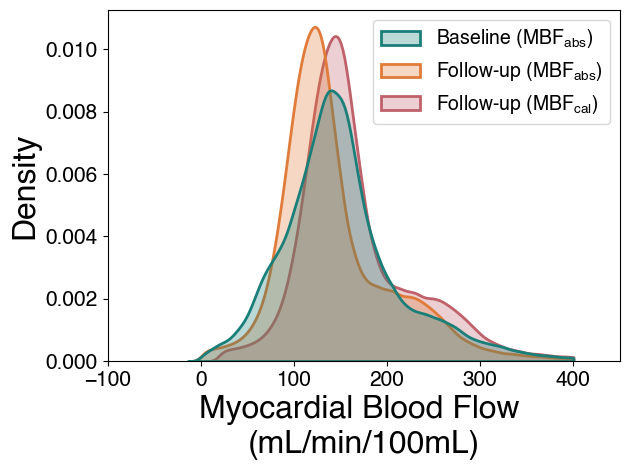

VA20
shift the mean


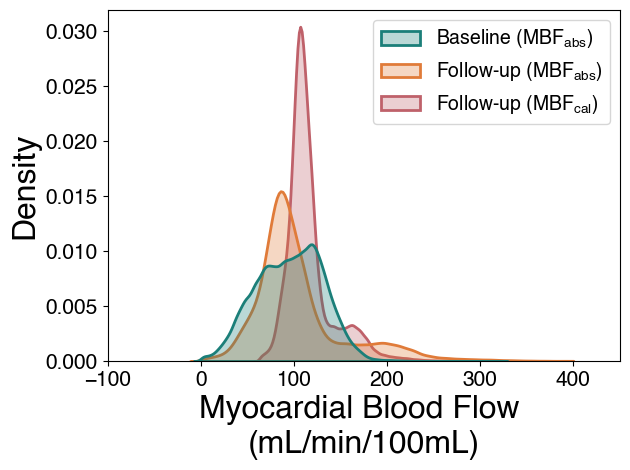

In [59]:
data = []
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    print(patient_id)
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])

    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)

    MBF_Array_A = GetMBFArray(MBF_A)
    MBF_Array_B = GetMBFArray(MBF_B)

    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    # ref_A = np.median(array_A)
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    # ref_B = np.median(array_B)
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)

    # ref_A = np.percentile(MBF_Array_A, 50)
    # ref_B = np.percentile(MBF_Array_B, 50)

    # Mapping using z-score of the nongrafted
    MBF_Array_B_mapped = MapNongrafted(mean_B, mean_A, std_B, std_A, MBF_Array_B)#ShiftMBF(ref_B, ref_A, MBF_Array_B) #

    palette = {
        'Baseline ($\\mathrm{MBF_{abs}}$)': '#1B7F79',
        'Follow-up ($\\mathrm{MBF_{abs}}$)': '#E07B39',
        'Follow-up ($\\mathrm{MBF_{cal}}$)': '#BF616A',
    }

    df = pd.DataFrame({
        'MBF':np.concatenate([MBF_Array_A, MBF_Array_B, MBF_Array_B_mapped]),
        'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_A) +
                ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_B) +
                ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * len(MBF_Array_B_mapped)
    })

    print("shift the mean")
    plt.rcParams['legend.fontsize'] = 14
    plt.figure()
    ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
                    fill=True, common_norm=False, palette=palette,
                alpha=.3, linewidth=2, clip=(-100, 400))
    ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    ax.set_ylabel("Density", fontsize = 23)
    #ax.legend()
    #plt.title(f"Patient {patient_id}")
    plt.xlim((-100, 450))
    #plt.ylim((0, 0.015))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    plt.show()


    # print("z-score mapping")

    # df = pd.DataFrame({
    #     'MBF':np.concatenate([MBF_Array_A, MBF_Array_B, MBF_Array_A_mapped2]),
    #     'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_A) +
    #             ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_B) +
    #             ['Baseline ($\\mathrm{MBF_{cal}}$)'] * len(MBF_Array_A_mapped2)
    # })

    # plt.rcParams['legend.fontsize'] = 14
    # plt.figure()
    # ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
    #                 fill=True, common_norm=False, palette="rocket_r",
    #             alpha=.3, linewidth=1, clip=(-100, 400))
    # ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    # ax.set_ylabel("Density", fontsize = 23)
    # #ax.legend()
    # #plt.title(f"Patient {patient_id}")
    # plt.xlim((-100, 450))
    # #plt.ylim((0, 0.015))
    # plt.xticks(fontsize=15)
    # plt.yticks(fontsize=15)
    # plt.tight_layout()
    # plt.show()

### Mapping based on the healthy modal from GMM (pre on post)

SU03
209.5701131759117
130.85364409324478
shift the mean


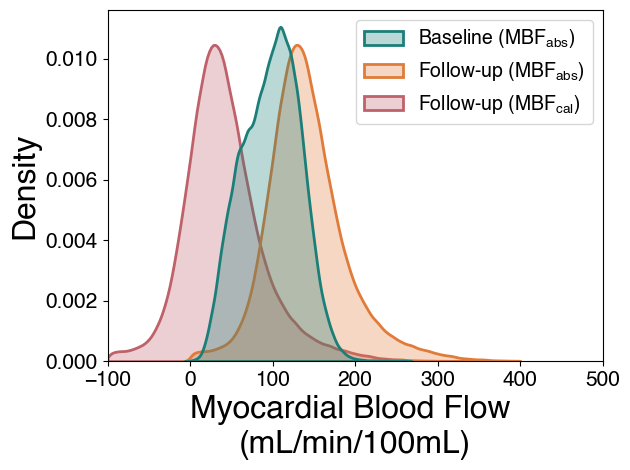

SU04
177.10275503803658
161.0300877576464
shift the mean


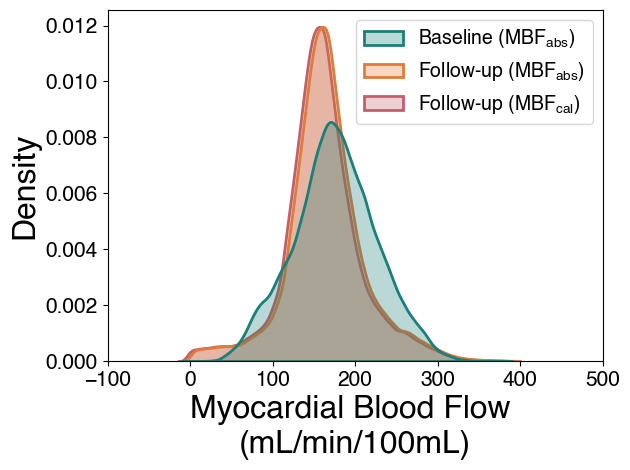

SU06
161.1898070862615
150.89408006884796
shift the mean


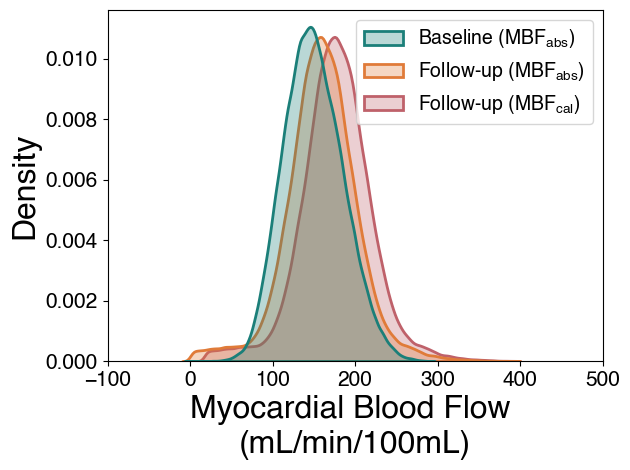

SU07
217.77690029615005
113.8441369442028
shift the mean


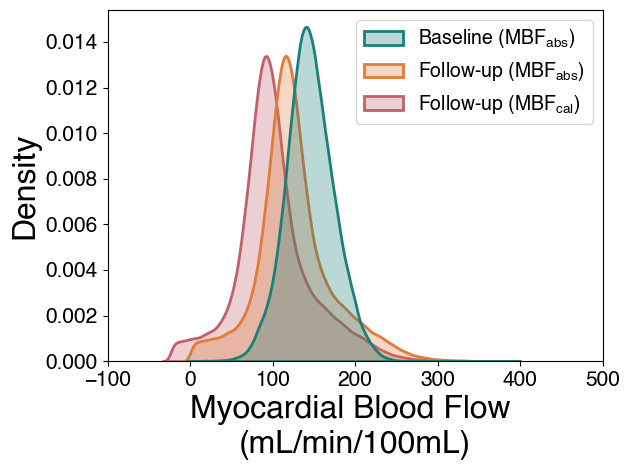

SU10
190.8008158845794
84.8242252115082
shift the mean


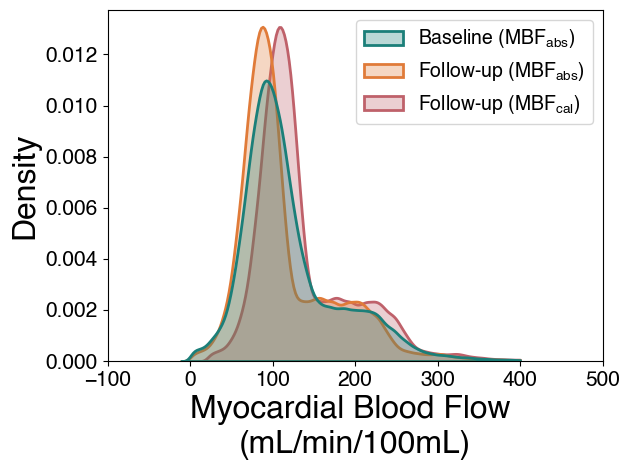

SU11
173.36065484459698
161.4172505318891
shift the mean


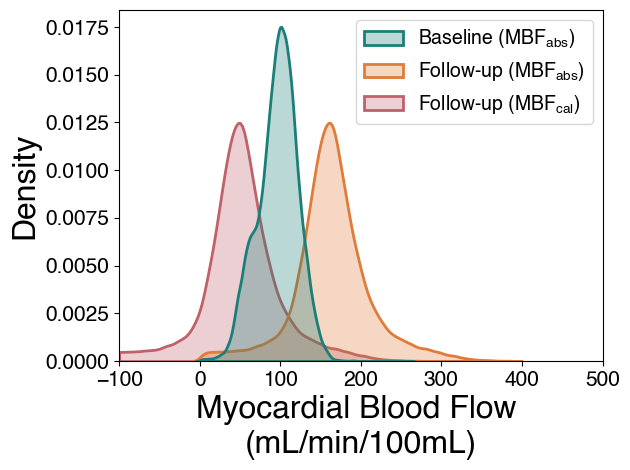

SU13
216.68865609664024
115.11068285041304
shift the mean


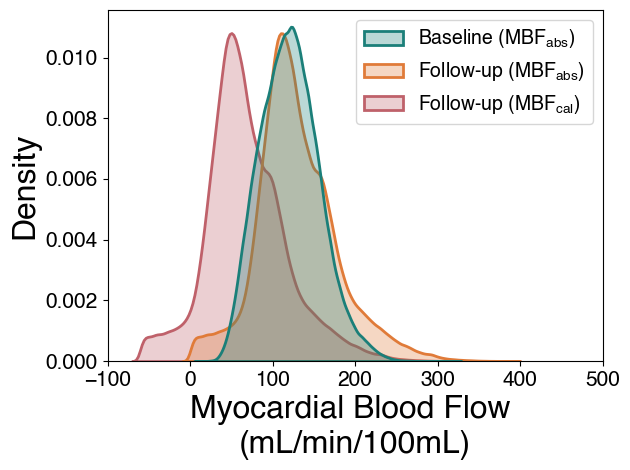

SU14
222.11911462450593
115.31877468422218
shift the mean


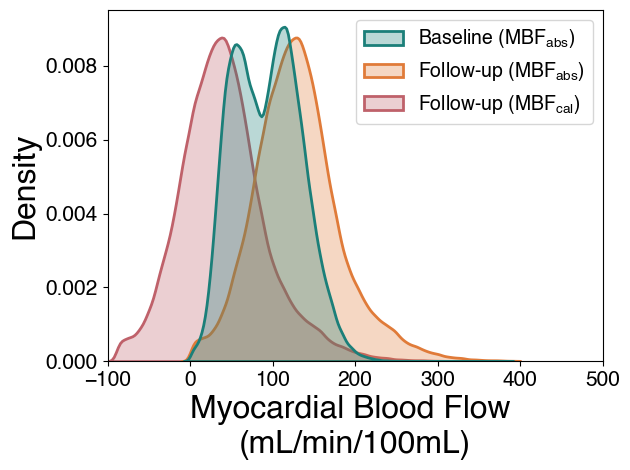

SU16
222.11911462450593
115.31877468422218
shift the mean


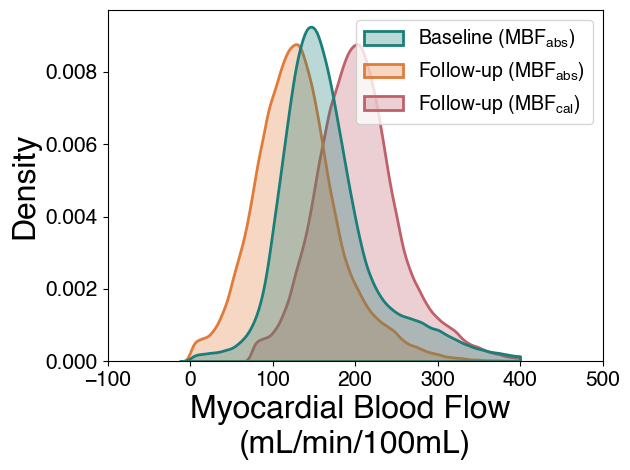

SU21
303.3502643523122
163.4381483681399
shift the mean


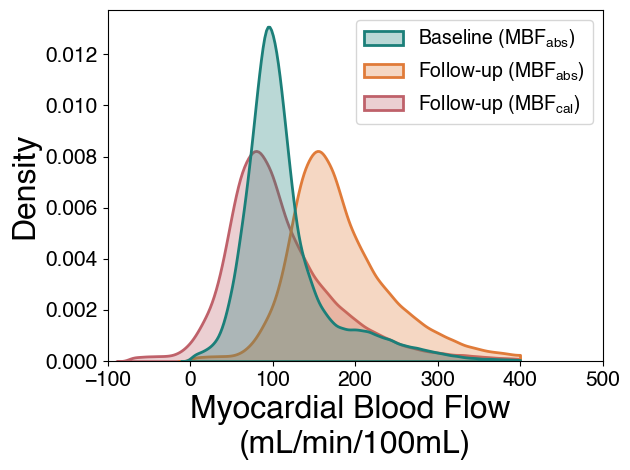

SU23
232.86948726046518
97.3323302974017
shift the mean


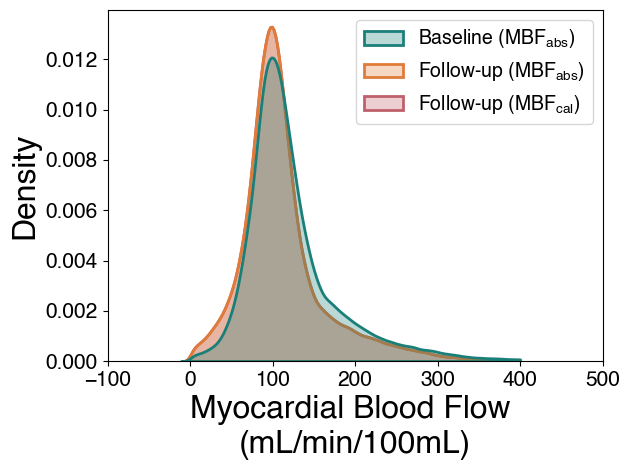

SU24
304.2416899870316
154.12585884910098
shift the mean


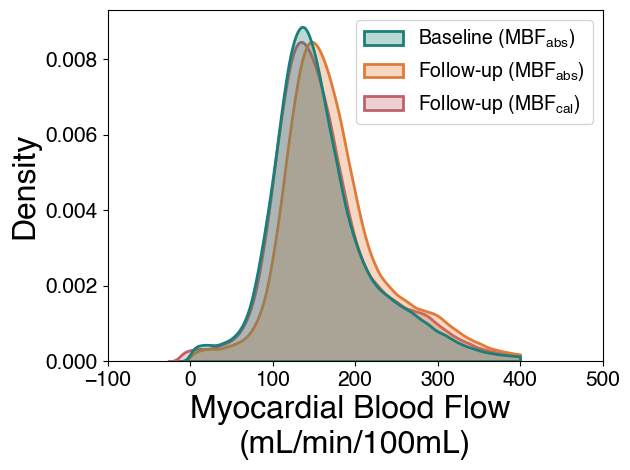

SU26
261.1587102893841
123.82304955583739
shift the mean


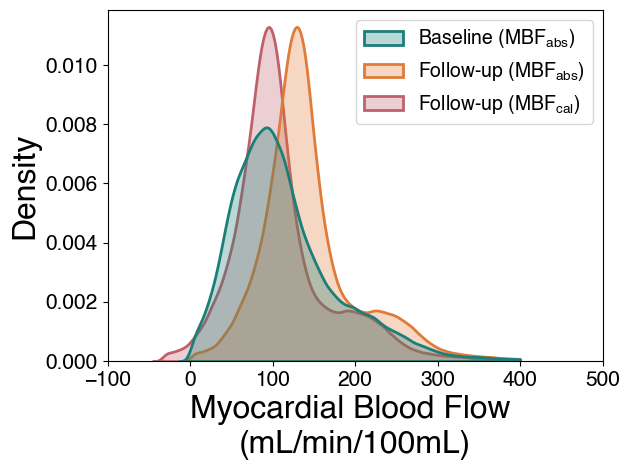

SU27
249.0882397698534
128.00165756031677
shift the mean


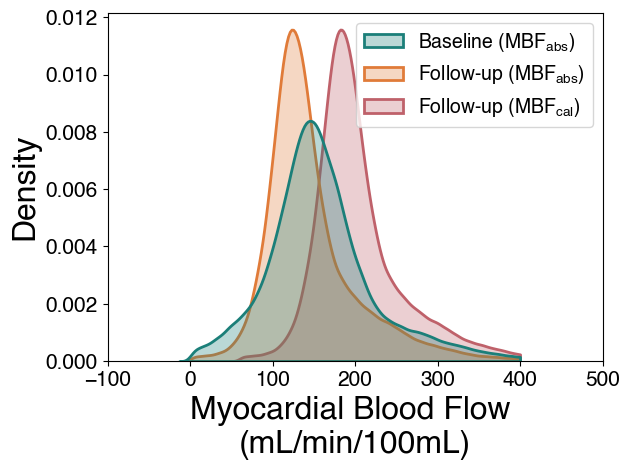

SU28
247.50758084929953
114.74577541752191
shift the mean


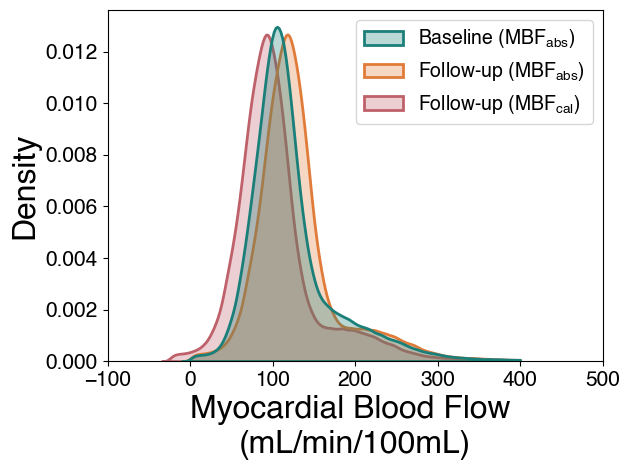

SU30
213.90804287208087
95.47502579495357
shift the mean


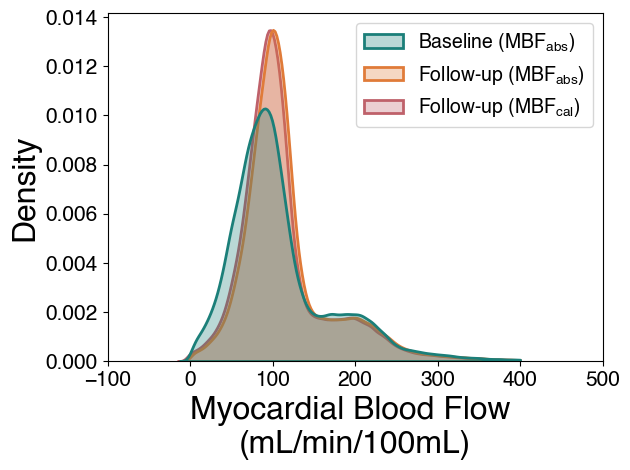

SU33
261.4640382223451
110.4584658912626
shift the mean


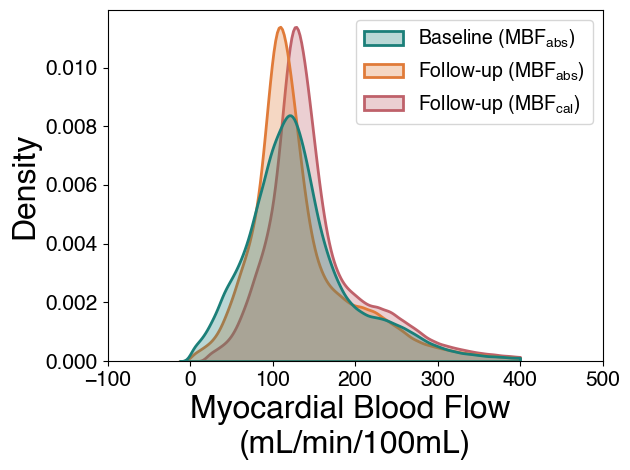

SU34
182.5229260834329
99.20660593038558
shift the mean


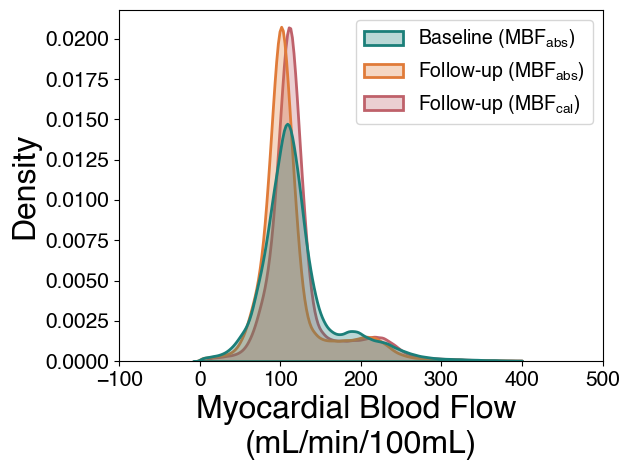

VA02
155.93713007350593
128.5470670715988
shift the mean


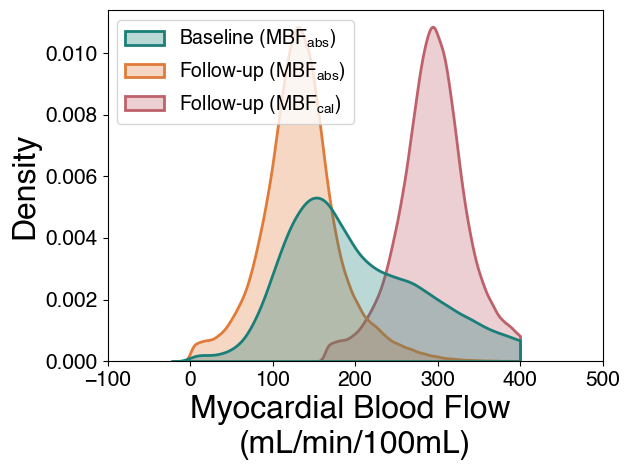

VA06
276.64523397904753
95.67933284417259
shift the mean


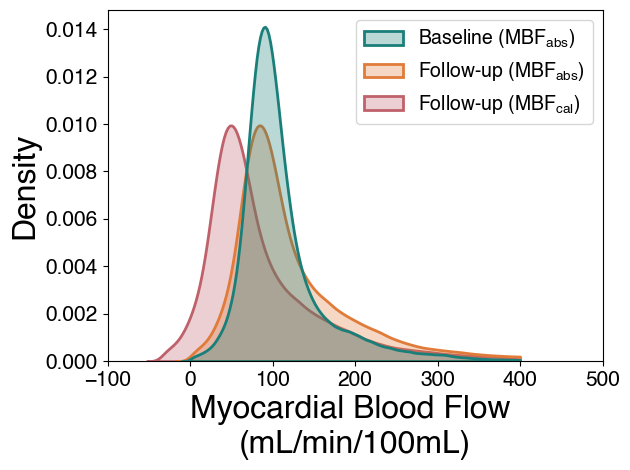

VA08
183.021779638458
93.92489425645593
shift the mean


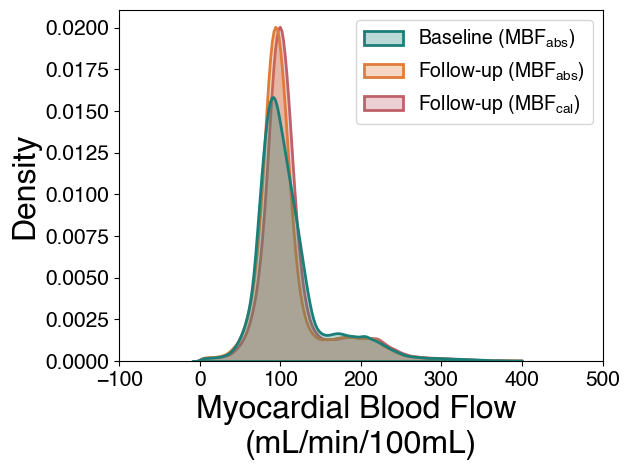

VA10
234.1565024197854
99.95030910570763
shift the mean


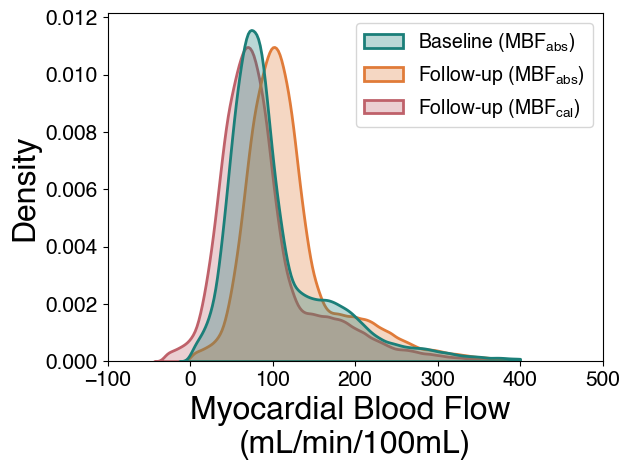

VA13
254.0564958872362
119.49034074496852
shift the mean


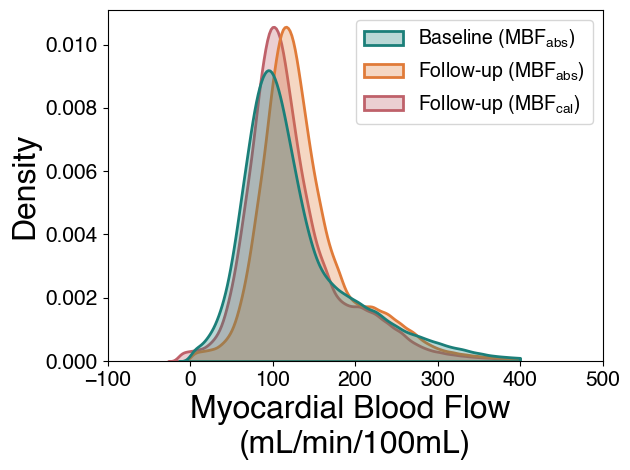

VA14
263.34611094485405
124.11814849982696
shift the mean


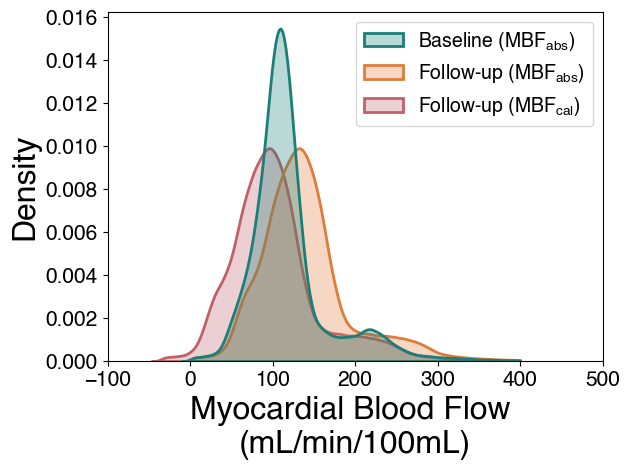

VA16
219.78589473271927
119.04514022325151
shift the mean


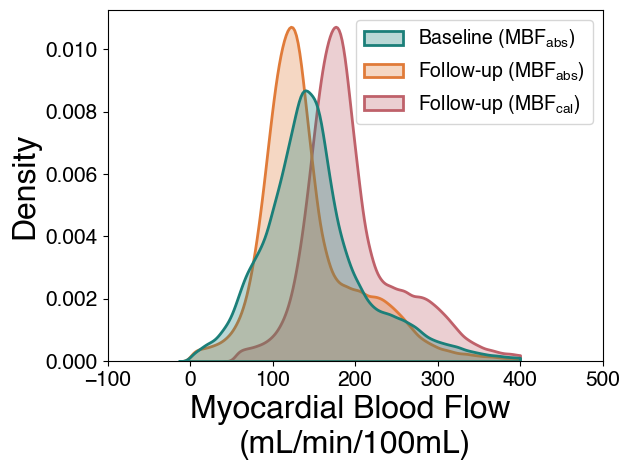

VA20
201.0450960449809
86.33237281093226
shift the mean


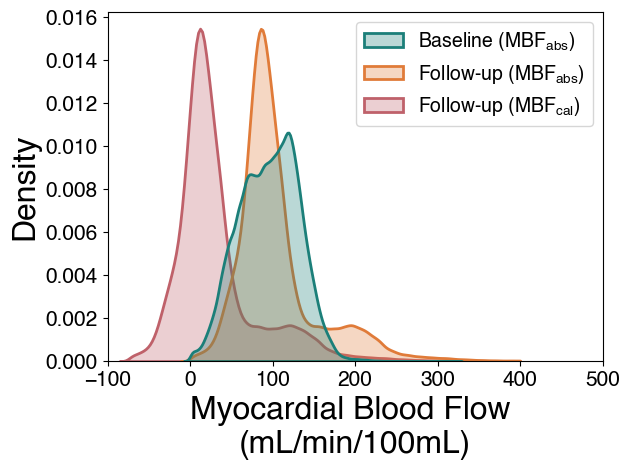

In [63]:
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    print(patient_id)
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    grafts = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['graft'])

    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = ReadVTUFile(file)

    MBF_Array_A = GetMBFArray(MBF_A)
    MBF_Array_B = GetMBFArray(MBF_B)

    AbsMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B = CollectMBFData(MBF_B, MBF_Labels)

    array = MBF_Array_A.reshape(-1, 1)

    gmm2 = GaussianMixture(n_components=2).fit(array)

    labels = gmm2.predict(array)
    clusters = [array[labels == 0].reshape(-1), array[labels == 1].reshape(-1)]
    order = np.argsort([np.mean(array[labels == 0]), np.mean(array[labels == 1])])
    diseased_A, healthy_A = [clusters[i] for i in order]


    array = MBF_Array_B.reshape(-1, 1)
    gmm2 = GaussianMixture(n_components=2).fit(array)
    
    labels = gmm2.predict(array)
    clusters = [array[labels == 0].reshape(-1), array[labels == 1].reshape(-1)]
    order = np.argsort([np.mean(array[labels == 0]), np.mean(array[labels == 1])])
    diseased_B, healthy_B = [clusters[i] for i in order]

    print(np.mean(healthy_B))
    print(np.mean(diseased_B))

    mean_A = np.mean(healthy_A)
    std_A = np.std(healthy_A)
    mean_B = np.mean(healthy_B)
    std_B = np.std(healthy_B)

    ref_A = np.median(healthy_A)
    ref_B = np.median(healthy_B)
    # Mapping based on the mean of the nongrafted
    MBF_Array_B_mapped = MBF_Array_B - (ref_B - ref_A)

    # Mapping using z-score of the nongrafted
    MBF_Array_A_mapped2 = MapNongrafted(mean_B, mean_A, std_B, std_A, MBF_Array_B)

    df = pd.DataFrame({
        'MBF':np.concatenate([MBF_Array_A, MBF_Array_B, MBF_Array_B_mapped]),
        'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_A) +
                ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_B) +
                ['Follow-up ($\\mathrm{MBF_{cal}}$)'] * len(MBF_Array_B_mapped)
    })

    print("shift the mean")
    plt.rcParams['legend.fontsize'] = 14
    plt.figure()
    ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
                    fill=True, common_norm=False, palette=palette,
                alpha=.3, linewidth=2, clip=(-100, 400))
    ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    ax.set_ylabel("Density", fontsize = 23)
    #ax.legend()
    #plt.title(f"Patient {patient_id}")
    plt.xlim((-100, 500))
    #plt.ylim((0, 0.015))
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.tight_layout()
    plt.show()


    # print("z-score mapping")

    # df = pd.DataFrame({
    #     'MBF':np.concatenate([MBF_Array_A, MBF_Array_B, MBF_Array_A_mapped2]),
    #     'Label': ['Baseline ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_A) +
    #             ['Follow-up ($\\mathrm{MBF_{abs}}$)'] * len(MBF_Array_B) +
    #             ['Baseline ($\\mathrm{MBF_{cal}}$)'] * len(MBF_Array_A_mapped2)
    # })

    # plt.rcParams['legend.fontsize'] = 14
    # plt.figure()
    # ax = sns.kdeplot(data=df, x="MBF", hue=df['Label'].tolist(),
    #                 fill=True, common_norm=False, palette="rocket_r",
    #             alpha=.3, linewidth=1, clip=(-100, 400))
    # ax.set_xlabel("Myocardial Blood Flow \n(mL/min/100mL)", fontsize = 23)
    # ax.set_ylabel("Density", fontsize = 23)
    # #ax.legend()
    # #plt.title(f"Patient {patient_id}")
    # plt.xlim((-100, 450))
    # #plt.ylim((0, 0.015))
    # plt.xticks(fontsize=15)
    # plt.yticks(fontsize=15)
    # plt.tight_layout()
    # plt.show()